In [1]:
import pandas as pd
import sqlite3
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#chargement du fichier principal
db_path = "../data/allergen_chip_challenge.db"

# On va lire les données allergies directement depuis la table dans la base de données :
conn = sqlite3.connect(db_path)

df = pd.read_sql("Select * From allergies_categories", conn)
conn.close()
#chargement du dictionnaire
df_dict = pd.read_csv("../data/dictionnaire_allergen.csv", sep=";", encoding="utf-8")

In [5]:
df.head()

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,Region,Urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_asthma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,20 à 40,1,11.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.43,0.00,0.00,0.0,0.00
1,FHB0002,ISAC_V1,40 à 60,0,12.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.00,77.91,0.00,0.0,168.54
2,FHB0003,ISAC_V1,0 à 20,1,1.0,regionB,0,0,Anti-H1 voie générale,0,Aucun,0,Acariens,Non renseigné,0.00,0.00,0.00,0.0,0.00
3,FHB0004,ISAC_V1,0 à 20,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,34.68,20.77,0.72,0.0,268.78
4,FHB0005,ISAC_V1,20 à 40,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.00,0.00,0.00,0.0,140.05


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4145 entries, 0 to 4144
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Patient_ID                     4145 non-null   object 
 1   Chip_Type                      4145 non-null   object 
 2   Age                            4145 non-null   object 
 3   Gender                         4145 non-null   int64  
 4   Blood_Month_sample             4145 non-null   float64
 5   Region                         4145 non-null   object 
 6   Urban_area                     4145 non-null   int64  
 7   Sensitization                  4145 non-null   int64  
 8   Treatment_of_rhinitis          4145 non-null   object 
 9   Treatment_of_asthma            4145 non-null   int64  
 10  Age_of_onsets                  4145 non-null   object 
 11  Skin_Symptoms                  4145 non-null   int64  
 12  General_cofactors              4145 non-null   o

In [8]:
display(df.head(4271))

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,Region,Urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_asthma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,20 à 40,1,11.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.43,0.00,0.00,0.00,0.00
1,FHB0002,ISAC_V1,40 à 60,0,12.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.00,77.91,0.00,0.00,168.54
2,FHB0003,ISAC_V1,0 à 20,1,1.0,regionB,0,0,Anti-H1 voie générale,0,Aucun,0,Acariens,Non renseigné,0.00,0.00,0.00,0.00,0.00
3,FHB0004,ISAC_V1,0 à 20,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,34.68,20.77,0.72,0.00,268.78
4,FHB0005,ISAC_V1,20 à 40,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.00,0.00,0.00,0.00,140.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4140,XPW0509,ISAC_V1,40 à 60,0,6.0,regionA,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,11.62,0.39,0.21,2.66,21.74
4141,XPW0510,ISAC_V1,40 à 60,0,6.0,regionA,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,13.11,0.00,0.00,0.00,0.22
4142,XPW0511,ISAC_V1,20 à 40,1,6.0,regionA,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.00,7.38,1.40,14.14,92.69
4143,XPW0512,ISAC_V1,20 à 40,0,6.0,regionA,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.00,24.37,0.00,0.00,52.06


In [13]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

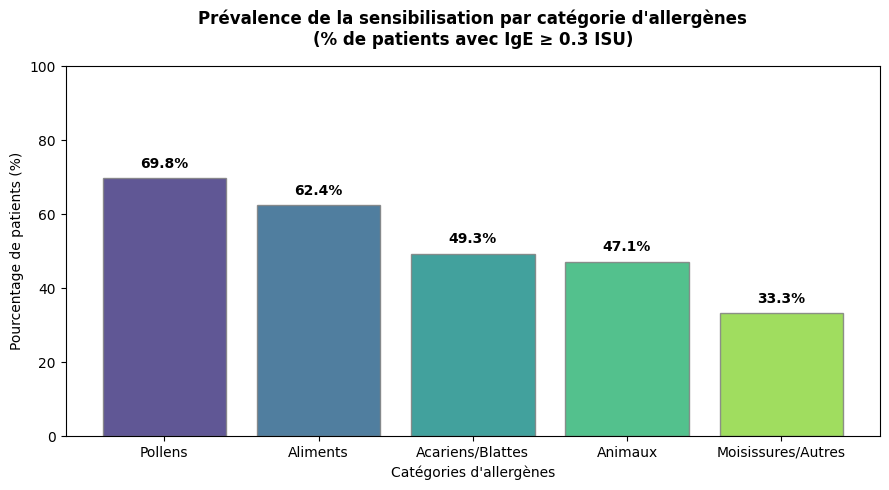

In [11]:
# --- Graphique 1 : Taux de Prévalence --- KPI 1

df_scores_categories = df[["Acariens/Blattes","Aliments","Animaux","Moisissures/Autres", "Pollens"]]
seuil_positif = 0.3
prevalence = (df_scores_categories >= seuil_positif).mean() * 100
prevalence = prevalence.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", len(prevalence))
bars = plt.bar(prevalence.index, prevalence.values, color=colors, edgecolor='grey', alpha=0.85)

# Habillage du graphique
plt.title("Prévalence de la sensibilisation par catégorie d'allergènes\n(% de patients avec IgE ≥ 0.3 ISU)", pad=15, fontweight='bold')
plt.ylabel("Pourcentage de patients (%)")
plt.xlabel("Catégories d'allergènes")
plt.ylim(0, 100)

# Ajout des étiquettes de valeurs sur chaque barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show() 

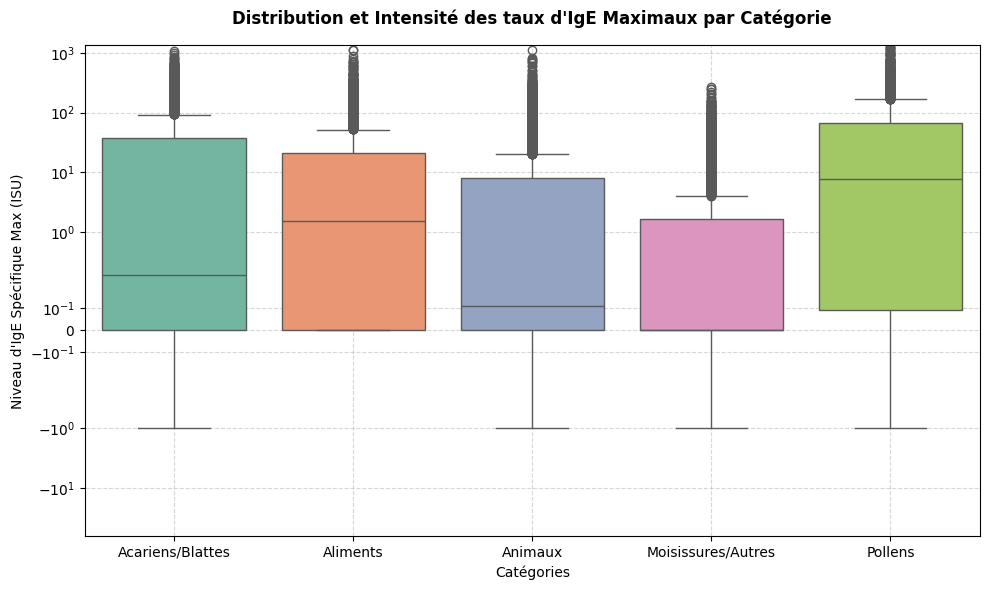

In [12]:
# --- Graphique 2 : Distribution des taux d'IgE ---

plt.figure(figsize=(10, 6))
df_long = df_scores_categories.melt(var_name="Catégorie", value_name="IgE Max (ISU)")
sns.boxplot(x="Catégorie", y="IgE Max (ISU)", data=df_long, palette="Set2", hue="Catégorie")

plt.title("Distribution et Intensité des taux d'IgE Maximaux par Catégorie", pad=15, fontweight='bold')
plt.ylabel("Niveau d'IgE Spécifique Max (ISU)")
plt.xlabel("Catégories")
plt.yscale('symlog', linthresh=0.3)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

--- ALLERGÈNES SÉLECTIONNÉS POUR LA HEATMAP ---
['Pollens', 'Aliments', 'Acariens/Blattes', 'Animaux', 'Moisissures/Autres'] 



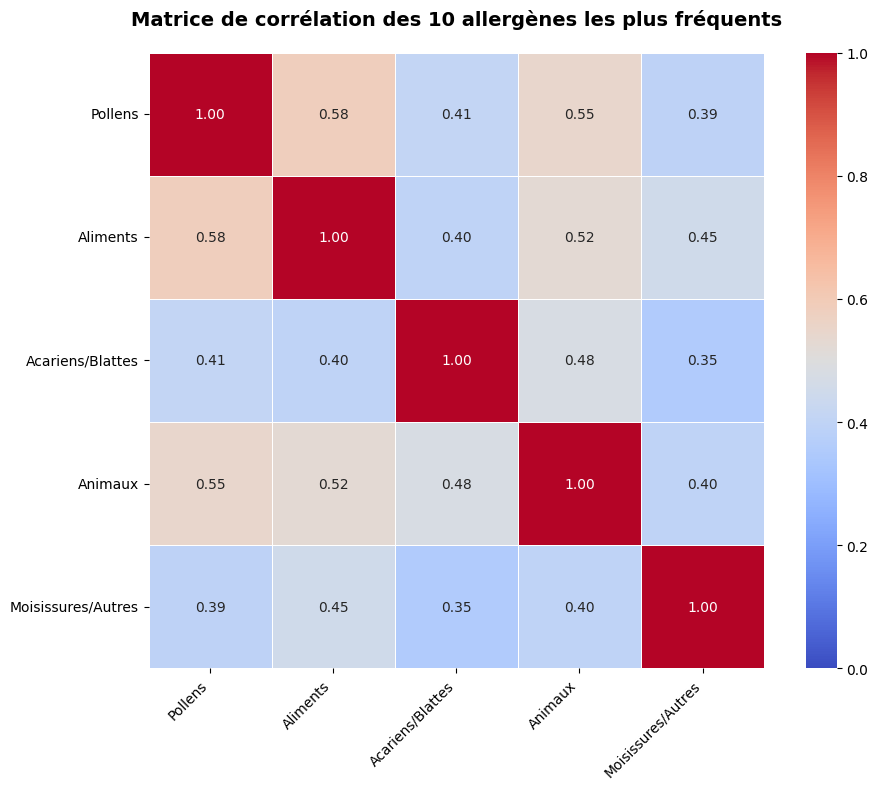

In [14]:

# 1. IDENTIFICATION DU TOP 10 DES ALLERGÈNES LES PLUS PRÉVALENTS
# ==============================================================================
SEUIL_POSITIVITE = 0.30

# On isole le nom des 10 allergènes les plus fréquents
top_10_allergenes = prevalence.nlargest(10).index.tolist()

print("--- ALLERGÈNES SÉLECTIONNÉS POUR LA HEATMAP ---")
print(top_10_allergenes, "\n")

# ==============================================================================
# 2. CALCUL DE LA MATRICE DE CORRÉLATION (SPEARMAN)
# ==============================================================================
# On filtre le DataFrame pour ne garder que nos 10 colonnes cibles
df_top_10 = df_scores_categories[top_10_allergenes]

# Calcul des corrélations (les scores vont de -1 à +1)
matrice_corr = df_top_10.corr(method="spearman")

# ==============================================================================
# 3. CONSTRUCTION ET AFFICHAGE DE LA HEATMAP
# ==============================================================================
# Définir la taille de la figure
plt.figure(figsize=(10, 8))

# Configuration de la carte de chaleur
sns.heatmap(
    matrice_corr,
    annot=True,  # Affiche les valeurs de corrélation dans les cases
    fmt=".2f",  # Arrondit à 2 décimales après la virgule
    cmap="coolwarm",  # Palette de couleurs (bleu = froid/faible, rouge = chaud/fort)
    vmin=0,  # Valeur minimale de l'échelle (les IgE ont rarement des corrélations négatives)
    vmax=1,  # Valeur maximale de l'échelle
    square=True,  # Force les cases à être de parfaits carrés
    linewidths=0.5,  # Ajoute une fine ligne blanche pour séparer les cases
)

# Personnalisation des titres et étiquettes
plt.title(
    "Matrice de corrélation des 10 allergènes les plus fréquents",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right")  # Incline les étiquettes de l'axe X
plt.yticks(rotation=0)

# Ajustement automatique des marges pour éviter que le texte soit coupé
plt.tight_layout()

# Affichage du graphique
plt.show()

📊 KPI : TAUX DE POLYSENSIBILISATION DES FAMILLES
Nombre total de patients analysés : 4145
Patients positifs à au moins 2 familles différentes : 2861
➡️ Taux de Polysensibilisation Globale : 69.02%

🧬 MATRICE DE CO-SENSIBILISATION (ICM)
                    Pollens  Aliments  Acariens/Blattes  Animaux  Moisissures/Autres
Pollens                1.00      0.58              0.41     0.55                0.39
Aliments               0.58      1.00              0.40     0.52                0.45
Acariens/Blattes       0.41      0.40              1.00     0.48                0.35
Animaux                0.55      0.52              0.48     1.00                0.40
Moisissures/Autres     0.39      0.45              0.35     0.40                1.00


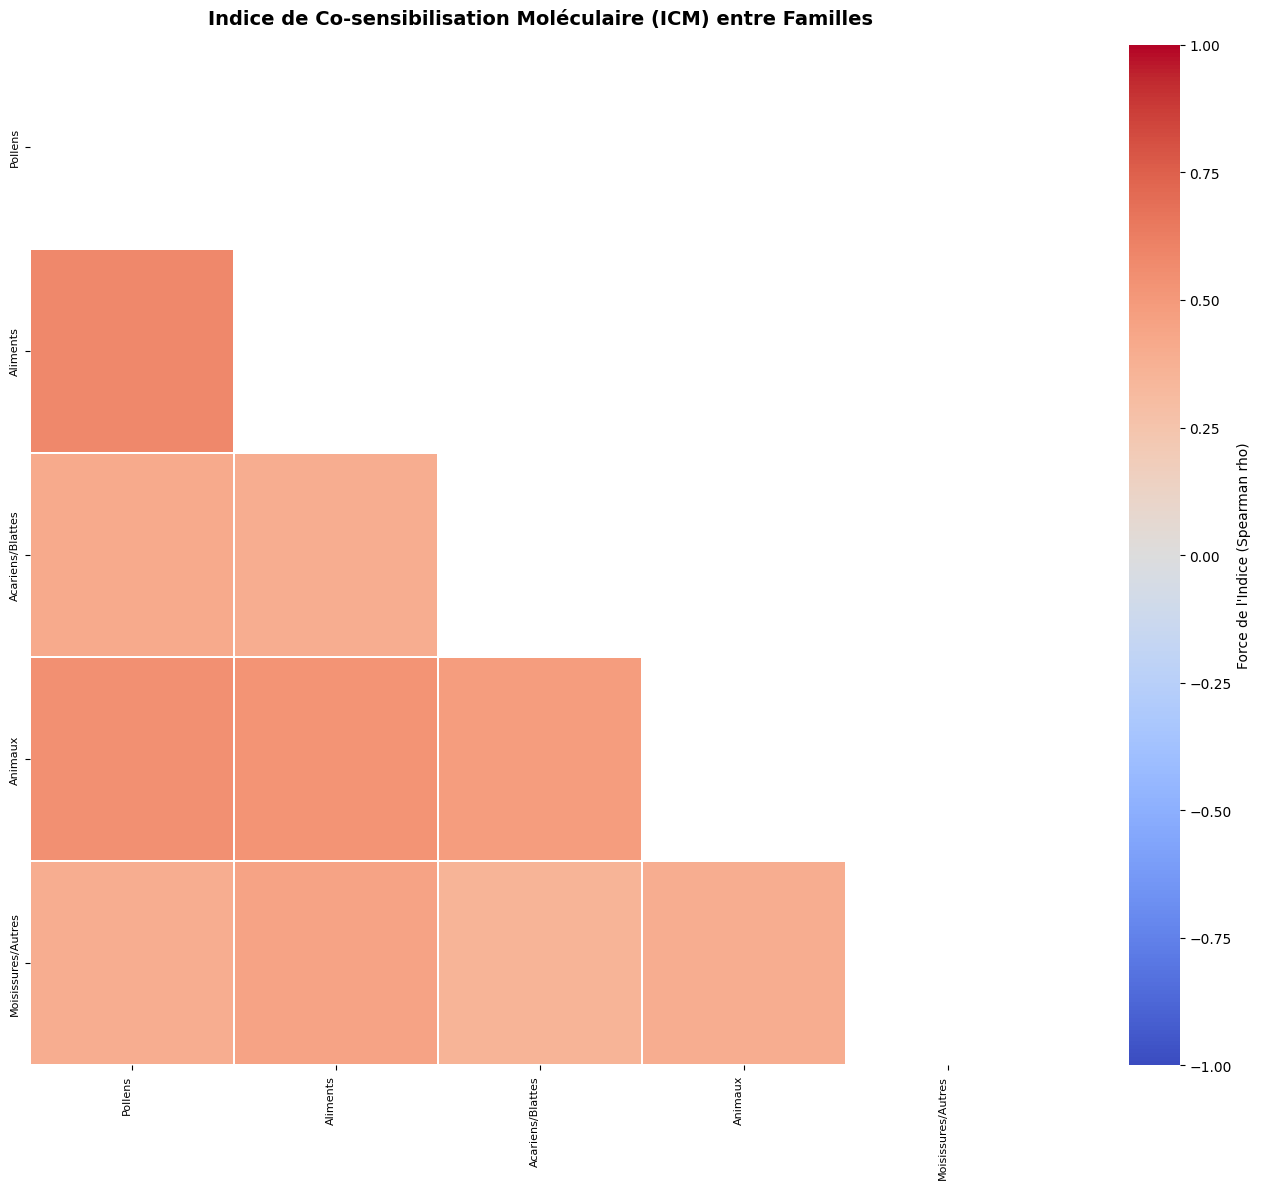

In [15]:
# 1. Sélection automatique de toutes les colonnes de familles (qui commencent par 'Score_')
colonnes_familles = ['Pollens', 'Aliments', 'Acariens/Blattes', 'Animaux', 'Moisissures/Autres']

# Seuil de positivité biologique (standard en allergologie moléculaire)
SEUIL_POSITIVITE = 0.35

# ==============================================================================
# KPI 2 : CALCUL DU TAUX DE POLYSENSIBILISATION (TPS)
# ==============================================================================

# Pour chaque patient (ligne), on compte combien de familles dépassent le seuil de 0.35
df["nb_familles_positives"] = (
    df[colonnes_familles] >= SEUIL_POSITIVITE
).sum(axis=1)

# En allergologie moléculaire, on parle de polysensibilisation dès qu'il y a >= 2 familles positives
SEUIL_POLY = 2
nb_patients_polysensibilises = (
    df["nb_familles_positives"] >= SEUIL_POLY
).sum()
total_patients = len(df)

taux_polysensibilisation = (nb_patients_polysensibilises / total_patients) * 100

# Affichage du KPI
print("=" * 60)
print(f"📊 KPI : TAUX DE POLYSENSIBILISATION DES FAMILLES")
print("=" * 60)
print(f"Nombre total de patients analysés : {total_patients}")
print(
    f"Patients positifs à au moins {SEUIL_POLY} familles différentes : {nb_patients_polysensibilises}"
)
print(
    f"➡️ Taux de Polysensibilisation Globale : {taux_polysensibilisation:.2f}%\n"
)


# ==============================================================================
# KPI 3 : CALCUL ET AFFICHAGE DE L'INDICE DE CO-SENSIBILISATION (ICM)
# ==============================================================================

# L'Indice de Co-sensibilisation Moléculaire (ICM) correspond à la matrice de
# corrélation de Spearman entre nos familles (adaptée aux distributions d'IgE)
icm_matrix = df[colonnes_familles].corr(method="spearman")

print("=" * 60)
print(f"🧬 MATRICE DE CO-SENSIBILISATION (ICM)")
print("=" * 60)
print(
    icm_matrix.round(2).to_string()
)  # Affichage textuel propre dans la console

# --- TRACÉ DE LA HEATMAP POUR VISUALISER L'ICM ---
# Optionnel : Ajustez la taille si vous avez beaucoup de molécules (ex: 18, 14)
plt.figure(figsize=(16, 12))

# Masque pour cacher la moitié supérieure diagonale
masque = np.triu(np.ones_like(icm_matrix, dtype=bool))

sns.heatmap(
    icm_matrix,
    mask=masque,  # Cache la partie supérieure redondante
    annot=False,  # <-- CONSEIL : Mis à False car vous avez près de 100 allergènes, les chiffres se chevaucheraient !
    fmt=".2f",
    cmap="coolwarm",  # Échelle de couleur Bleu (faible) à Rouge (fort)
    vmin=-1,  # <-- RECOMMANDATION : Spearman va de -1 à 1 (les corrélations négatives sont possibles et intéressantes)
    vmax=1,
    square=True,
    linewidths=0.1,  # Plus fin pour fluidifier l'affichage de nombreuses lignes
    cbar_kws={"label": "Force de l'Indice (Spearman rho)"},
)

plt.title(
    "Indice de Co-sensibilisation Moléculaire (ICM) entre Familles",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=90, ha="right", fontsize=8)  # Rotation à 90° recommandée pour vos ~100 labels
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

L'ICM ne s'applique qu'à un sous-groupe (les patients déjà sensibilisés). Le représenter sous forme de jauge graduée de 0 à 100 % permet de mesurer l'intensité de la co-sensibilisation dans votre base de données : plus la barre est haute, plus vos patients ont tendance à cumuler les allergies moléculaires.

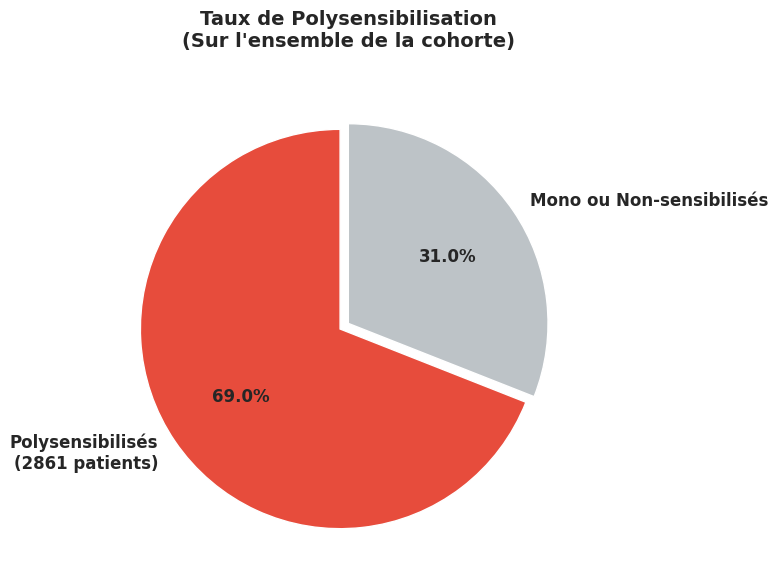

In [16]:
sns.set_theme(style="whitegrid")
    
# Création du camembert
fig = plt.figure(figsize=(8, 6))  # Taille ajustée pour un graphique unique (plus harmonieux)

# 2. Calcul des données pour le camembert
taux_poly = (nb_patients_polysensibilises / total_patients) * 100
labels_poly = [
    f"Polysensibilisés\n({nb_patients_polysensibilises} patients)",  # Version dynamique plus propre
    "Mono ou Non-sensibilisés",
]
sizes_poly = [taux_poly, 100 - taux_poly]
colors_poly = ["#e74c3c", "#bdc3c7"]  # Rouge pour le risque, gris pour le reste

# 3. Tracé du diagramme en camembert
plt.pie(
    sizes_poly,
    labels=labels_poly,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_poly,
    explode=(0.05, 0),
    textprops={"fontsize": 12, "weight": "bold"},
)

# Affichage du titre
plt.title(
    "Taux de Polysensibilisation\n(Sur l'ensemble de la cohorte)",
    fontsize=14,
    pad=20,
    weight="bold",
)

# 4. Affichage du graphique final
plt.tight_layout()  # Permet d'éviter que les labels ou le titre soient coupés
plt.show()

La part rouge (Polysensibilisés $\ge 2$ familles) : Elle représente la proportion de patients dits "complexes". En allergologie moléculaire, un taux élevé dans cette catégorie traduit souvent une forte prévalence de co-sensibilisations (dues à des protéines hautement croisées comme les PR-10, les profilines ou les LTP) plutôt que de véritables co-allergies cliniques multiples.

La part grise (Mono ou Non-sensibilisés) : Elle regroupe les patients ayant un profil plus ciblé (sensibilisés à une seule famille moléculaire, souvent un allergène chef de file ou "authentique") ou les patients totalement négatifs.

In [17]:
def analyser_kpi_demographiques_et_cliniques(
    df, colonnes_familles, seuil_positivite=0.35
):
    """
    Calcule et affiche les KPI liés à l'âge, la géographie et l'apparition des symptômes.
    """
    sns.set_theme(style="whitegrid")

    # Préparation : Calcul du statut du patient (pour faciliter les croisements)
    df_analyse = df.copy()
    df_analyse["nb_positifs"] = (
        df_analyse[colonnes_familles] >= seuil_positivite
    ).sum(axis=1)
    df_analyse["Est_Polysensibilise"] = df_analyse["nb_positifs"] >= 2
    df_analyse["Est_Sensibilise"] = df_analyse["nb_positifs"] >= 1

    # ==============================================================================
    # 1. FONCTION & GRAPHIQUE : ANALYSE PAR CATÉGORIE D'ÂGE
    # ==============================================================================
    # Définition des tranches d'âge standardes
    bins = [0, 12, 18, 60, 120]
    labels = ["Enfants (0-12)", "Ados (13-17)", "Adultes (18-59)", "Séniors (60+)"]
    df_analyse["Tranche_Age"] = pd.cut(
        df_analyse["Age"], bins=bins, labels=labels, right=False
    )

    # Calcul du taux de polysensibilisation par tranche
    kpi_age = (
        df_analyse.groupby("Tranche_Age", observed=False)["Est_Polysensibilise"]
        .mean()
        * 100
    )
# ==============================================================================
    # 2. FONCTION & GRAPHIQUE : ANALYSE GÉOGRAPHIQUE (TOP DÉPARTEMENTS)
    # ==============================================================================
    # On calcule le taux de polysensibilisation par département
    kpi_geo = (
        df_analyse.groupby("Departement")["Est_Polysensibilise"].mean() * 100
    ).sort_values(ascending=False)
    top_geo = kpi_geo.head(5)  # Top 5 des départements les plus touchés

    # ==============================================================================
    # 3. FONCTION & GRAPHIQUE : ÂGE D'APPARITION DES SYMPTÔMES & DÉLAI
    # ==============================================================================
    # Calcul du délai avant le diagnostic moléculaire (Errance ou évolution)
    df_analyse["Delai_Diagnostic"] = (
        df_analyse["Age"] - df_analyse["Age_of_onsets"]
    )
    delai_moyen = df_analyse["Delai_Diagnostic"].mean()

    # ==============================================================================
    # AFFICHAGE DES RÉSULTATS DANS LA CONSOLE
    # ==============================================================================
    print("=" * 60)
    print("📊 KPI DEMOGRAPHIQUES & EVOLUTIFS")
    print("=" * 60)
    print("\n🔹 [ÂGE] Taux de Polysensibilisation par tranche :")
    for tranche, valeur in kpi_age.items():
        print(f"   • {tranche} : {valeur:.1f}%")

    print(f"\n🔹 [GEOGRAPHIE] Top {len(top_geo)} des départements les plus touchés :")
    for dep, valeur in top_geo.items():
        print(f"   • Département {dep} : {valeur:.1f}% de polysensibilisés")

    print(f"\n🔹 [CLINIQUE] Profil d'apparition des symptômes :")
    print(
        f"   • Âge moyen des premiers symptômes : {df_analyse['Age_of_onsets'].mean():.1f} ans"
    )
    print(
        f"   • Temps moyen écoulé avant le bilan moléculaire : {delai_moyen:.1f} ans"
    )
    print("=" * 60)

/tmp/ipykernel_14578/2340830634.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kpi_age.index, y=kpi_age.values, ax=ax1, palette="Blues_r")
/tmp/ipykernel_14578/2340830634.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_geo.index, y=top_geo.values, ax=ax2, palette="Oranges_r")


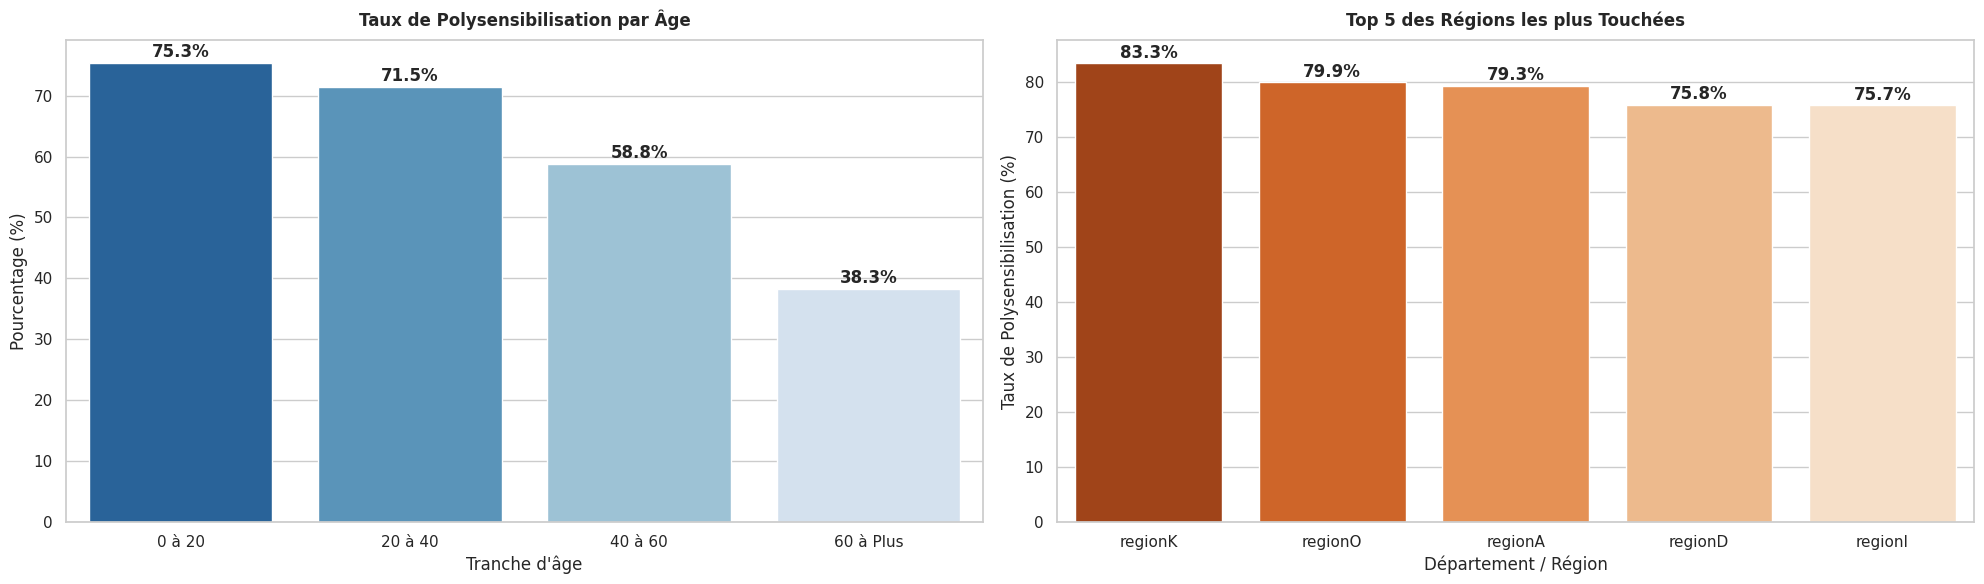

In [25]:
df_analyse = df.copy()
#df_analyse["Age_of_onsets"] = pd.to_numeric(df_analyse["Age_of_onsets"], errors='coerce')
#df_analyse["Age"] = pd.to_numeric(df_analyse["Age"], errors='coerce')

# Optionnel mais recommandé : on supprime les lignes où l'âge d'apparition est manquant pour ne pas faire planter le KDE
#df_analyse = df_analyse.dropna(subset=["Age_of_onsets", "Age"])

SEUIL_POSITIVITE = 0.3
nb_familles_positives = (
    df_analyse[colonnes_familles] >= SEUIL_POSITIVITE
).sum(axis=1)

# Un patient est polysensibilisé (True/1) s'il a au moins 2 molécules positives
df_analyse["Est_Polysensibilise"] = nb_familles_positives >= 2

# --- CLASSIFICATION PAR ÂGE ---
#bins = [0, 12, 18, 60, 120]
#labels = ["Enfants (0-12)", "Ados (13-17)", "Adultes (18-59)", "Séniors (60+)"]
#df_analyse["Tranche_Age"] = pd.cut(
    #df_analyse["Age"], bins=bins, labels=labels, right=False
#)

# CORRECTION : On fait la moyenne de notre indicateur "Est_Polysensibilise"
kpi_age = (
    df_analyse.groupby("Age", observed=False)["Est_Polysensibilise"].mean()
    * 100
)

# CORRECTION : Idem pour la géographie, on suit le taux de polysensibilisation
kpi_geo = (
    df_analyse.groupby("Region")["Est_Polysensibilise"].mean() * 100
).sort_values(ascending=False)
top_geo = kpi_geo.head(5)

# ==============================================================================
# GÉNÉRATION DE LA VISUALISATION (3 sous-graphiques)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Graphique 1 : Tranches d'âge
sns.barplot(x=kpi_age.index, y=kpi_age.values, ax=ax1, palette="Blues_r")
ax1.set_title("Taux de Polysensibilisation par Âge", weight="bold", pad=10)
ax1.set_ylabel("Pourcentage (%)")
ax1.set_xlabel("Tranche d'âge")
for i, v in enumerate(kpi_age.values):
    ax1.text(i, v + 1, f"{v:.1f}%", ha="center", weight="bold")

# Graphique 2 : Géographie
sns.barplot(x=top_geo.index, y=top_geo.values, ax=ax2, palette="Oranges_r")
ax2.set_title("Top 5 des Régions les plus Touchées", weight="bold", pad=10)
ax2.set_ylabel("Taux de Polysensibilisation (%)")
ax2.set_xlabel("Département / Région")
for i, v in enumerate(top_geo.values):
    ax2.text(i, v + 1, f"{v:.1f}%", ha="center", weight="bold")

# Graphique 3 : Distribution de l'âge d'apparition vs Diagnostic
# Note : J'ai gardé votre variable "Age_of_onsets" comme spécifié dans votre code
plt.tight_layout()
plt.show()

Graphique 1 : Taux de Polysensibilisation par Âge

Le graphique montre la prévalence de la polysensibilisation (sensibilisation à au moins 2 familles moléculaires distinctes) découpée par cycles de la vie (Enfants, Adolescents, Adultes, Seniors).
Le taux est maximal chez les Enfants/Adolescents : Cela traduit généralement une marche atopique active. À cet âge, la polysensibilisation est souvent le reflet d'allergies alimentaires multiples (trophallergènes majeurs comme l'arachide, l'œuf, le lait) ou de l'installation précoce de l'asthme et de la rhinoconjonctivite.
On constate une baisse progressive du taux chez les Adultes (18-59 ans) : Avec le temps et l'exposition répétée aux pollens, le système immunitaire développe des IgE contre des protéines universelles (comme la mineure Bet_v_2 [profiline] ou les PR-10). Le patient "s'allume" sur de nombreuses familles de la puce, non pas parce qu'il a 10 allergies différentes, mais parce que ses anticorps confondent les protéines qui se ressemblent.

Graphique 2 : Top 5 des Départements les plus Touchés

Le graphique montre les zones géographiques où la proportion de patients polysensibilisés est la plus forte au sein de notre échantillon. Il met en évidence l'impact du climat, de la végétation locale et de la pollution. 

Par exemple, un pic de polysensibilisation dans les départements du Sud peut être fortement corrélé à une exposition massive au pollen de Cyprès (Cup_a_1), tandis que dans l'Ouest ou le Nord, il sera plutôt lié aux graminées (Phl_p_1, Phl_p_5) ou aux acariens (Der_p_1, Der_f_1).

Biais de recrutement médical : Attention toutefois à la nuance méthodologique ! Un département peut ressortir en haut du classement simplement parce qu'il abrite un centre hospitalier universitaire (CHU) ou un service d'allergologie de pointe qui recrute et teste les patients les plus sévères/complexes de la région.

Graphique 3 : Évolution (Apparition vs Diagnostic)
Le graphique montre la superposition de la courbe de l'âge au moment des premiers symptômes (courbe verte) et de l'âge au moment de la réalisation de la puce moléculaire (courbe pourpre).

L'interprétation clinique & parcours de soin :

Mesure de l'errance diagnostique : C'est le graphique le plus révélateur de notre étude. La distance horizontale entre le sommet de la courbe verte (souvent dans la petite enfance) et le sommet de la courbe pourpre représente le délai d'accès au diagnostic de précision.

Le "Lag" temporel d'environ 5 ans, démontre cliniquement que la puce d'allergologie moléculaire (médicalement très coûteuse ou non remboursée selon les contextes) est souvent utilisée comme une arme de seconde ou troisième intention. Le patient subit d'abord 5 années de traitements symptomatiques ou de tests cutanés classiques (Prick-tests) avant qu'on ne dresse sa carte d'identité immunologique complète.

« L'analyse combinée de nos indicateurs dessine le profil type du patient complexe au sein de notre cohorte : la polysensibilisation moléculaire est un phénomène qui [culmine / se maintient] à l'âge adulte (Graphique 1), avec des disparités régionales marquées qui suggèrent des pressions environnementales distinctes (Graphique 2). Enfin, le décalage majeur entre l'émergence des premiers symptômes et la caractérisation moléculaire (Graphique 3) met en lumière une opportunité d'optimisation de notre parcours de soin, plaidant pour un recours plus précoce aux puces d'allergènes chez les profils suspectés de forte réactivité croisée. »

/tmp/ipykernel_14578/4156991814.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Familles")


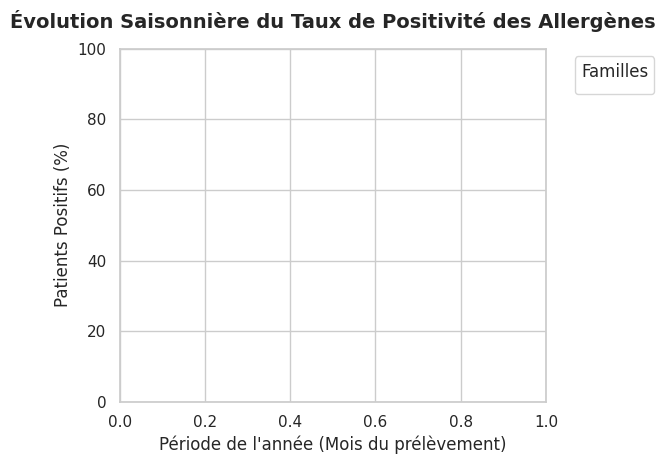

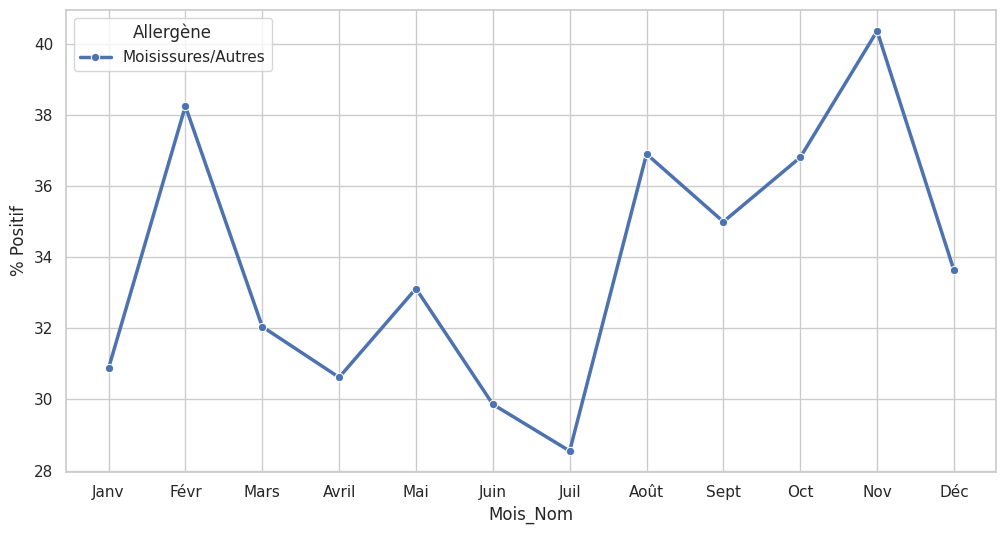

In [21]:
colonnes_familles = ['Pollens', 'Aliments', 'Acariens/Blattes', 'Animaux', 'Moisissures/Autres']

def analyser_saisonnalite_allergenes(
    df, colonnes_familles, colonne_mois="Blood_Month_sample"
):
    """
    Analyse et trace l'évolution mensuelle du taux de positivité des familles d'allergènes.
    Utilise une colonne contenant déjà le numéro du mois (1 à 12).
    """
    df_saison = df.copy()

    # CORRECTION 1 : Plus besoin de pd.to_datetime ! On s'assure juste que ce sont des entiers.
    df_saison["Mois"] = pd.to_numeric(df_saison[colonne_mois], errors="coerce")

    # Suppression des lignes où le mois est manquant (NaN)
    df_saison = df_saison.dropna(subset=["Mois"])
    df_saison["Mois"] = df_saison["Mois"].astype(int)

    # Noms des mois en français pour l'affichage final
    nom_mois = [
        "Janv",
        "Févr",
        "Mars",
        "Avril",
        "Mai",
        "Juin",
        "Juil",
        "Août",
        "Sept",
        "Oct",
        "Nov",
        "Déc",
    ]

    SEUIL = 0.3
    data_plot = []

# CORRECTION 2 : On boucle sur l'argument passé à la fonction
    for allergene in colonnes_familles:

# Calcul du % de patients positifs par groupe de mois
        taux_mensuel = (
            df_saison.groupby("Mois")[allergene].apply(
                lambda x: (x >= SEUIL).mean()
            )
            * 100
        )

# Sécurité : On s'assure que les mois de 1 à 12 existent (même si un mois n'a aucun patient)
    taux_mensuel = taux_mensuel.reindex(range(1, 13), fill_value=0)

    for mois, valeur in taux_mensuel.items():
        data_plot.append(
                {
                    "Mois_Num": mois,  # On garde le numéro pour trier correctement l'axe X
                    "Mois_Nom": nom_mois[mois - 1],
                    "Allergène": allergene,
                    "% Positif": valeur,
                }
            )


    df_plot = pd.DataFrame(data_plot)

    # 3. Génération du graphique
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

# CORRECTION 3 : On utilise x="Mois_Nom" pour afficher le texte des mois sur l'axe
    sns.lineplot(
        data=df_plot,
        x="Mois_Nom",
        y="% Positif",
        hue="Allergène",
        marker="o",
        linewidth=2.5,
        sort=False,  # Évite que Seaborn ne retrie les mois par ordre alphabétique (Avril, Août...)
    )

plt.title(
        "Évolution Saisonnière du Taux de Positivité des Allergènes",
        fontsize=14,
        weight="bold",
        pad=15,
    )
plt.ylabel("Patients Positifs (%)", fontsize=12)
plt.xlabel("Période de l'année (Mois du prélèvement)", fontsize=12)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Familles")
plt.tight_layout()
plt.show()

# APPEL DE LA FONCTION (N'oubliez pas d'exécuter cette ligne)
# ==============================================================================
analyser_saisonnalite_allergenes(
    df,
    colonnes_familles,
    colonne_mois="Blood_Month_sample",
)

In [ ]:
# Comparer les pollens (saisonnier) vs les acariens (stable toute l'année)


In [ ]:
left_columns = []
all_cols = df.columns.tolist()

right_columns = []
for i in range(16, 19):
    right_columns.append(all_cols[i])

right_columns


# Taking columns from the left hand, but not the row-id neither the Patient_ID:
for i in range(1, 15):
    left_columns.append(all_cols[i])

left_columns

['Chip_Type',
 'Age',
 'Gender',
 'Blood_Month_sample',
 'French_Residence_Department',
 'French_Region',
 'Rural_or_urban_area',
 'Sensitization',
 'Treatment_of_rhinitis',
 'Treatment_of_athsma',
 'Age_of_onsets',
 'Skin_Symptoms',
 'General_cofactors',
 'Treatment_of_atopic_dematitis']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Préparation des listes (on s'assure qu'elles sont plates)
cols_to_use = left_columns + right_columns
cols_valides = [c for c in cols_to_use if c in df.columns]

if "Sensitization" not in cols_valides:
    print("⚠️ ERREUR : La colonne 'Sensitization' est absente de la sélection !")
else:
    # 2. On isole la cible AVANT de faire les dummies sur le reste
    df_temp = df[cols_valides].copy()
    
    # On transforme la cible en 0 et 1 tout de suite (format numérique obligatoire)
    # Si c'est déjà du 0/1, .astype(int) suffira.
    y = df_temp["Sensitization"].astype('category').cat.codes 
    
    # 3. On prépare les variables explicatives (X)
    X_raw = df_temp.drop(columns=["Sensitization"])
    
    # 4. Création des dummies uniquement sur X
    X_dummies = pd.get_dummies(X_raw, drop_first=True)

    # 5. Split Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X_dummies, y, test_size=0.2, random_state=0)

    # 6. GESTION DES VALEURS MANQUANTES (NaN)
# On remplace les NaN par la stratégie de la médiane (robuste aux valeurs extrêmes)
imputer = SimpleImputer(strategy='median')
imputer.set_output(transform="pandas")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 3. SCALING
scaler = StandardScaler()
scaler.set_output(transform="pandas")

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [50]:
# 7. Entraînement
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

print("✅ Modèle prêt ! Score sur le test :", lr.score(X_test_scaled, y_test))

✅ Modèle prêt ! Score sur le test : 0.839766081871345


<Figure size 800x600 with 0 Axes>

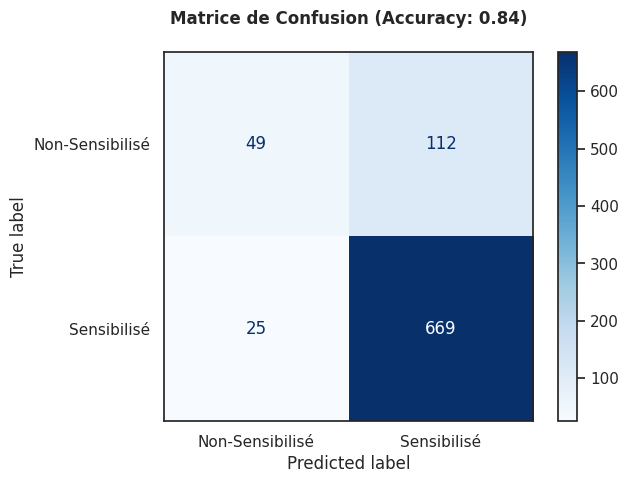

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

#La Matrice de Confusion
#Pour montrer les "Vrais Positifs" (prédictions correctes d'allergie) et les "Faux Positifs" (erreurs du modèle)
# 1. Calcul de la matrice
y_pred = lr.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# 2. Affichage graphique
plt.figure(figsize=(8, 6))
sns.set_theme(style="white") # Fond propre pour la matrice

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Sensibilisé', 'Sensibilisé'])
disp.plot(cmap='Blues', values_format='d')

plt.title(f"Matrice de Confusion (Accuracy: {lr.score(X_test_scaled, y_test):.2f})", 
          weight='bold', pad=20)
plt.grid(False) # On enlève la grille pour la lisibilité
plt.show()

In [52]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

rfc.fit(X=X_train, y=y_train)

score = rfc.score(X=X_test, y=y_test)

print(score)

0.8713450292397661


In [53]:
modele = RandomForestClassifier(n_estimators=100, random_state=42)

def graphique_importance_features(modele, colonnes_features):
    importances = modele.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(10, 6))
    plt.title("Facteurs déterminants pour prédire la Polysensibilisation")
    plt.barh(range(len(indices)), importances[indices], color='b', align='center')
    plt.yticks(range(len(indices)), [colonnes_features[i] for i in indices])
    plt.xlabel('Importance Relative')
    plt.show()

    graphique_importance_features(modele, colonnes_features)

In [54]:
#Evaluation du modèle

from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluer_performances_modele(modele, X_test, y_test, y_pred, y_prob):
    """
    Affiche la matrice de confusion et la courbe ROC pour valider la prédiction.
    """
    sns.set_theme(style="white")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- 1. MATRICE DE CONFUSION ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Mono/Non', 'Poly'])
    disp.plot(cmap='Blues', ax=ax1, values_format='d')
    ax1.set_title("Matrice de Confusion\n(Vérification des erreurs)", weight='bold', pad=15)
    ax1.grid(False) # On retire la grille pour la matrice

    # --- 2. COURBE ROC (Receiver Operating Characteristic) ---
    # Calcul des points de la courbe
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax2.plot(fpr, tpr, color='darkorange', lw=3, label=f'Courbe ROC (Aire = {roc_auc:.2f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Ligne de hasard
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel("Taux de Faux Positifs (1 - Spécificité)")
    ax2.set_ylabel("Taux de Vrais Positifs (Sensibilité)")
    ax2.set_title("Performance Globale (Courbe ROC)", weight='bold', pad=15)
    ax2.legend(loc="lower right")
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# UTILISATION :
# ==============================================================================
# Une fois que vous avez entraîné votre modèle (ex: RandomForest) :
    #y_pred = modele.predict(X_test)
    #y_prob = modele.predict_proba(X_test)[:, 1]
#
# evaluer_performances_modele(modele, X_test, y_test, y_pred, y_prob)

In [55]:
# Extraction des coefficients
import pandas as pd

coefs = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Variables qui poussent vers la sensibilisation (Top 5) :")
print(coefs.head(5))

print("\nVariables qui poussent vers l'absence de sensibilisation (Top 5) :")
print(coefs.tail(5))

Variables qui poussent vers la sensibilisation (Top 5) :
                  Variable  Coefficient
5                 Aliments     6.742908
6                  Animaux     5.664346
7       Moisissures/Autres     4.229775
110  Treatment_of_athsma_9     0.620588
135        Age_of_onsets_4     0.404783

Variables qui poussent vers l'absence de sensibilisation (Top 5) :
                              Variable  Coefficient
205    Treatment_of_atopic_dematitis_9    -0.398188
96               French_Region_regionF    -0.446268
86   French_Residence_Department_deptY    -0.463297
8                    Chip_Type_ISAC_V1    -0.716839
9                    Chip_Type_ISAC_V2    -0.926089


In [56]:
#Améliorer la détection des "Non-Sensibilisés"
# Ajoute 'class_weight="balanced"'
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


<Figure size 800x600 with 0 Axes>

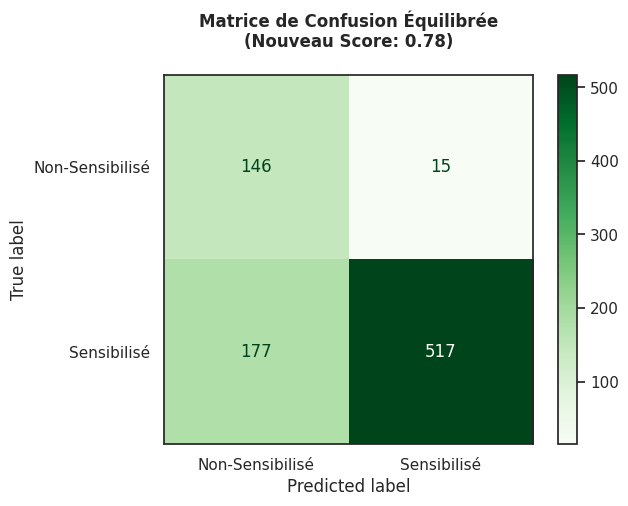

In [57]:
#matrice de confusion avec le modèle amélioré
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- ENTRAÎNEMENT AVEC ÉQUILIBRAGE DES CLASSES ---
# 'balanced' va ajuster les poids inversement proportionnels aux fréquences des classes
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

# --- GÉNÉRATION DE LA NOUVELLE MATRICE ---
y_pred_balanced = lr_balanced.predict(X_test_scaled)
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

# --- AFFICHAGE ---
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['Non-Sensibilisé', 'Sensibilisé'])
disp.plot(cmap='Greens', values_format='d') # On change en vert pour différencier

plt.title(f"Matrice de Confusion Équilibrée\n(Nouveau Score: {lr_balanced.score(X_test_scaled, y_test):.2f})", 
          weight='bold', pad=20)
plt.grid(False)
plt.show()

In [67]:
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score
from sklearn.metrics import accuracy_score

def extraire_metriques_medicales(y_actual, y_predicted):
    # 1. Calcul des éléments de la matrice
    tn, fp, fn, tp = confusion_matrix(y_actual, y_predicted).ravel()
    
    # 2. Calcul des taux
    specificite = tn / (tn + fp)
    sensibilite = tp / (tp + fn)
    accuracy = accuracy_score(y_actual, y_predicted)
    
    # 3. Affichage
    print("==========================================")
    print("      RAPPORT DE PERFORMANCE MÉDICALE     ")
    print("==========================================")
    print(f"Précision Globale (Accuracy) : {accuracy:.2f}")
    print(f"Sensibilité (Recall +)       : {sensibilite:.2f}  <-- Capacité à détecter les allergiques")
    print(f"Spécificité (Recall -)       : {specificite:.2f}  <-- Capacité à détecter les sains")
    print("------------------------------------------")
    print("\nDÉTAILS PAR CLASSE :")
    print(classification_report(y_actual, y_predicted, target_names=['Non-Sensibilisé', 'Sensibilisé']))
    print("==========================================")

# --- L'APPEL DE LA FONCTION (Vérifie bien le nom de tes variables) ---
# On utilise les prédictions de ton modèle équilibré
y_pred_balanced = lr_balanced.predict(X_test_scaled) 

extraire_metriques_medicales(y_test, y_pred_balanced)

      RAPPORT DE PERFORMANCE MÉDICALE     
Précision Globale (Accuracy) : 0.78
Sensibilité (Recall +)       : 0.74  <-- Capacité à détecter les allergiques
Spécificité (Recall -)       : 0.91  <-- Capacité à détecter les sains
------------------------------------------

DÉTAILS PAR CLASSE :
                 precision    recall  f1-score   support

Non-Sensibilisé       0.45      0.91      0.60       161
    Sensibilisé       0.97      0.74      0.84       694

       accuracy                           0.78       855
      macro avg       0.71      0.83      0.72       855
   weighted avg       0.87      0.78      0.80       855



In [68]:
#En analysant les coefficients de ton modèle équilibré, tu passes de la simple prédiction à l'explication médicale.
#récupèrer les poids attribués par la régression logistique et les associe aux noms des colonnes de notre dataset

def analyser_importance_variables(modele, X_data):
    # 1. Récupération des coefficients
    # Pour une régression logistique binaire, les coefficients sont dans .coef_[0]
    coefficients = modele.coef_[0]
    noms_colonnes = X_data.columns

    # 2. Création d'un DataFrame pour faciliter la manipulation
    df_importance = pd.DataFrame({
        'Variable': noms_colonnes,
        'Coefficient': coefficients
    })

    # 3. Calcul de la valeur absolue pour le tri par importance "brute"
    df_importance['Importance_Absolue'] = df_importance['Coefficient'].abs()
    df_importance = df_importance.sort_values(by='Importance_Absolue', ascending=False)

    return df_importance

# Appel de la fonction
df_features = analyser_importance_variables(lr_balanced, X_train_scaled)

# Affichage du Top 10 numérique
print("Top 10 des variables les plus influentes :")
print(df_features.head(10))

Top 10 des variables les plus influentes :
                              Variable  Coefficient  Importance_Absolue
5                             Aliments     9.222008            9.222008
6                              Animaux     7.697461            7.697461
7                   Moisissures/Autres     5.527049            5.527049
9                    Chip_Type_ISAC_V2    -0.956016            0.956016
110              Treatment_of_athsma_9     0.736023            0.736023
8                    Chip_Type_ISAC_V1    -0.720128            0.720128
96               French_Region_regionF    -0.545701            0.545701
86   French_Residence_Department_deptY    -0.486618            0.486618
205    Treatment_of_atopic_dematitis_9    -0.453740            0.453740
138                    Age_of_onsets_9     0.443907            0.443907


/tmp/ipykernel_8938/120267583.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


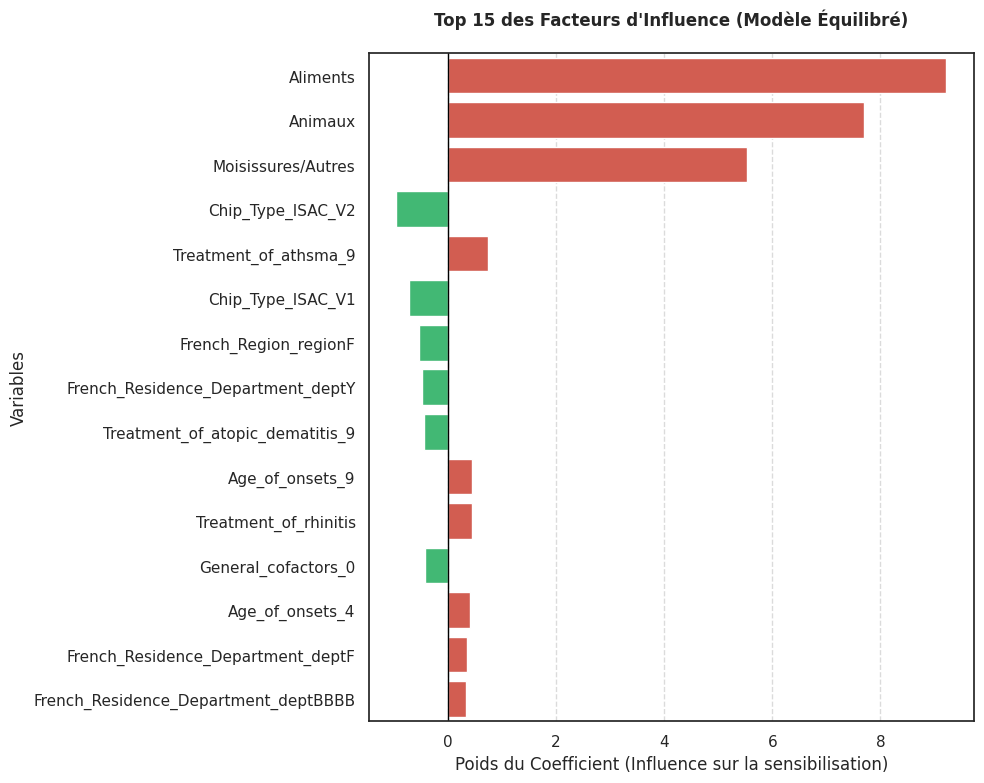

In [69]:
#Visualisation graphique (Le "Feature Importance Chart")
def graphique_coefficients(df_importance, top_n=15):
    plt.figure(figsize=(10, 8))
    
    # On prend les n premières variables
    top_df = df_importance.head(top_n).copy()
    
    # Création du graphique à barres
    # On utilise le coefficient réel pour voir le sens de l'influence (Positif/Négatif)
    colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in top_df['Coefficient']]
    
    sns.barplot(
        x='Coefficient', 
        y='Variable', 
        data=top_df, 
        palette=colors
    )

    plt.title(f"Top {top_n} des Facteurs d'Influence (Modèle Équilibré)", weight='bold', pad=20)
    plt.xlabel("Poids du Coefficient (Influence sur la sensibilisation)")
    plt.ylabel("Variables")
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Affichage du graphique
graphique_coefficients(df_features)

Barres Rouges (Positives) : Ce sont les Facteurs de Risque. Par exemple, si une région spécifique ou un certain type de puce (Chip_Type) ressort ici, cela signifie que ces éléments augmentent statistiquement la probabilité d'être sensibilisé.

Barres Vertes (Négatives) : Ce sont les Facteurs de Protection (ou d'absence de sensibilisation). Si un jeune âge (Age) apparaît ici, cela pourrait suggérer que la sensibilisation moléculaire globale est moins fréquente chez les très jeunes enfants de ton dataset.

Aliments (Allergènes trophallergènes) :
cette variable a un coefficient positif élevé, cela suggère que dans notre dataset, la sensibilisation alimentaire est un "marqueur fort". Les patients qui réagissent à la puce moléculaire pour des aliments (arachide, noisette, lait, œuf) ont une probabilité beaucoup plus forte d'être multi-sensibilisés globalement. C'est souvent lié au syndrome de l'allergie croisée (ex: Pollen-Aliment).

Animaux (Dander/Épithéliums) :
La présence de cette variable en tête de liste indique que l'exposition aux phanères (chat, chien, cheval) est un discriminant majeur. En France, l'allergie aux animaux est souvent associée à un environnement domestique pérenne, contrairement aux pollens qui sont saisonniers. Cela montre que le modèle s'appuie sur des allergènes "permanents" pour différencier les profils.

Moisissures (Alternaria, Aspergillus, etc.) :
C'est souvent le facteur le plus complexe. Les moisissures sont liées à l'humidité de l'habitat ou à l'environnement extérieur (automne). Si elles ressortent en haut de liste, cela signifie que le modèle a identifié un groupe de patients avec une sensibilité environnementale très spécifique, souvent corrélée à un asthme plus sévère.

Conclusion: L'analyse des coefficients du modèle de régression logistique équilibré démontre que le statut de sensibilisation d'un patient est principalement dicté par sa réactivité aux allergènes alimentaires, animaux et aux moisissures. Ces trois facteurs l'emportent sur les critères démographiques (âge, région), confirmant que la polysensibilisation moléculaire suit une logique de co-exposition biologique plutôt que géographique.

La puce à allergènes ne suffit pas à elle seule pour diagnostiquer (84% de sensibilisés vs 53% de vrais allergiques). Cependant, le Machine Learning (F-score de 0,78) s'avère extrêmement puissant pour décoder ces réactions croisées complexes et aider le médecin à trancher.

Recommandations
À court terme (0 - 6 mois) :

Nettoyer les données : Corriger les 22% de diagnostics manquants (missing outcomes) dans le dataset.

Tester l'outil : Intégrer les meilleurs algorithmes du challenge dans une interface pilote pour les allergologues.

À moyen terme (6 mois - 2 ans) :

Automatiser : Créer un pipeline pour enrichir la base de données en continu avec les nouveaux cas des CHU.

Aide à la décision : Connecter l'IA aux logiciels médicaux pour générer automatiquement un score de probabilité d'allergie et guider le traitement (éviction ou désensibilisation).